# MedLDLMO-CWS revisado: PSO, ablação, múltiplas sementes e monitor visual

Este notebook substitui a parte experimental do modelo proposto. Ele foi estruturado para responder diretamente aos pareceres:

- **cinco sementes** e apresentação de média ± desvio-padrão;
- **ablação fatorial** de PSO, CWS, amostragem balanceada e reponderação de classes;
- seleção do checkpoint exclusivamente por **macro-AUC de validação**;
- avaliação do conjunto de teste apenas depois da seleção do checkpoint;
- PSO reproduzível, com parâmetros, candidatos, custo computacional e histórico;
- comparação do PSO com arquitetura manual e **random search com o mesmo orçamento**;
- análise explícita do trade-off **Drusen × Normal**;
- exportação de métricas, previsões, matrizes de confusão, históricos e tabelas LaTeX.

> O CWS do notebook original não estava conectado ao treinamento. Aqui ele é definido explicitamente como **class-wise subgroup sampling**: DME e Drusen são particionadas em subgrupos visuais usando somente imagens do treino (PCA + MiniBatchKMeans). A exposição dos subgrupos é controlada pelo sampler, sem utilizar validação ou teste na criação dos grupos.

> Esta edição inclui barras de progresso, métricas por época, curvas atualizadas durante o treinamento, ETA e uso de memória. As pastas de saída de `smoke` e `final` são separadas automaticamente.


In [1]:
!pip install -q medmnist albumentations scikit-learn scipy pandas matplotlib tqdm opencv-python-headless ipywidgets psutil "jinja2>=3.1.5"


In [2]:
from __future__ import annotations

import copy
import gc
import itertools
import json
import math
import os
import random
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import albumentations as A
import matplotlib.pyplot as plt
import medmnist
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
from medmnist import INFO
from IPython.display import display
from scipy.stats import wilcoxon
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import label_binarize
from torch.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset, Subset, WeightedRandomSampler
from tqdm import tqdm

warnings.filterwarnings("ignore")


## 1. Configuração

Execute primeiro em `MODE = "smoke"`. Quando o notebook terminar sem erros, altere para `MODE = "final"` e execute novamente do início.

O modo final reproduz o orçamento declarado no artigo para o PSO: 4 partículas, 5 iterações e treinamento proxy de 3 épocas.


In [3]:
MODE = "final"  # "smoke" ou "final"
assert MODE in {"smoke", "final"}

CLASS_NAMES = ["CNV", "DME", "Drusen", "Normal"]
NUM_CLASSES = len(CLASS_NAMES)
DRUSEN_CLASS = 2
NORMAL_CLASS = 3
MINORITY_CLASSES = (1, 2)  # DME e Drusen

MANUAL_CHANNELS = [16, 32, 64, 96, 128]
PREVIOUS_PSO_CHANNELS = [31, 55, 60, 108, 160]

RESULTS_DIR = Path(f"results_medldlmo_revised_{MODE}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "predictions").mkdir(exist_ok=True)
(RESULTS_DIR / "histories").mkdir(exist_ok=True)
(RESULTS_DIR / "confusion_matrices").mkdir(exist_ok=True)
(RESULTS_DIR / "figures").mkdir(exist_ok=True)

if MODE == "smoke":
    SEEDS = [42]
    MAX_EPOCHS = 2
    PATIENCE = 2
    PROXY_EPOCHS = 1
    PROXY_SEEDS = [2026]
    PSO_SWARM_SIZE = 2
    PSO_MAX_ITER = 1
    PROXY_TRAIN_FRACTION = 0.02
    EXPERIMENT_SCOPE = "smoke"
else:
    SEEDS = [42, 123, 456, 789, 2026]
    MAX_EPOCHS = 50
    PATIENCE = 7
    PROXY_EPOCHS = 3
    # Usar mais de uma seed torna a busca arquitetural menos sensível ao ruído.
    # Se o custo for proibitivo, use somente [2026] e declare essa limitação.
    PROXY_SEEDS = [101, 202, 303]
    PSO_SWARM_SIZE = 4
    PSO_MAX_ITER = 5
    PROXY_TRAIN_FRACTION = 1.0
    EXPERIMENT_SCOPE = "core"  # "core" ou "full_factorial"

BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.3
MIN_DELTA = 1e-4
NUM_WORKERS = 2
CWS_N_CLUSTERS = 3
CWS_SEED = 2026
RUN_PSO_SEARCH = True
RUN_RANDOM_SEARCH = True

# Visualização compacta do progresso. Não altera o treinamento.
SHOW_EPOCH_PROGRESS = True       # uma única barra por treinamento
SHOW_BATCH_PROGRESS = False      # evita uma barra por lote
SHOW_PROXY_PROGRESS = False      # evita barras internas durante PSO/random search
PRINT_EPOCH_SUMMARY = False      # métricas ficam na própria barra
SAVE_TRAINING_PLOTS = True       # salva curvas em RESULTS_DIR/figures
SHOW_FINAL_PLOT = MODE == "smoke"  # no final, não exibe 50 gráficos no notebook

PSO_LOWER_BOUNDS = np.array([8, 16, 32, 48, 64], dtype=float)
PSO_UPPER_BOUNDS = np.array([32, 64, 96, 128, 160], dtype=float)
PSO_INERTIA = 0.729
PSO_COGNITIVE = 1.49445
PSO_SOCIAL = 1.49445

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = device.type == "cuda"

print("Modo:", MODE)
print("Dispositivo:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Modo: final
Dispositivo: cuda
GPU: NVIDIA GeForce RTX 5090


In [4]:
print("Versões principais:")
print("  Python:", os.sys.version.split()[0])
print("  PyTorch:", torch.__version__)
print("  Pandas:", pd.__version__)
print("  Jinja2:", __import__("jinja2").__version__)
print("  MedMNIST:", medmnist.__version__)
print("  Albumentations:", A.__version__)
print("  scikit-learn:", __import__("sklearn").__version__)
print("  tqdm:", __import__("tqdm").__version__)
print("  CPU threads:", os.cpu_count())
print("  RAM disponível:", f"{psutil.virtual_memory().available / (1024 ** 3):.2f} GB")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("  GPU:", props.name)
    print("  VRAM total:", f"{props.total_memory / (1024 ** 3):.2f} GB")
else:
    print("  GPU: não disponível")


Versões principais:
  Python: 3.11.6
  PyTorch: 2.13.0+cu130
  Pandas: 3.0.5
  Jinja2: 3.1.6
  MedMNIST: 3.0.2
  Albumentations: 2.0.8
  scikit-learn: 1.9.0
  tqdm: 4.66.1
  CPU threads: 32
  RAM disponível: 45.40 GB
  GPU: NVIDIA GeForce RTX 5090
  VRAM total: 31.36 GB


In [5]:
def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_generator(seed: int) -> torch.Generator:
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


seed_everything(SEEDS[0])


## 2. OCTMNIST e pré-processamento

- São usadas as divisões oficiais de treino, validação e teste.
- A entrada permanece em **um canal** e resolução nativa de **28×28**.
- A normalização é `(x - 0.5) / 0.5`, coerente com treinamento do zero.
- O mesmo conjunto de transformações é disponibilizado a todas as classes. O CWS altera exposição amostral, não escolhe transformações diferentes para classes minoritárias.
- O teste não recebe aumento de dados.


In [6]:
def build_train_transform(image_size: int = 28) -> A.Compose:
    transforms = []
    if image_size != 28:
        transforms.append(A.Resize(image_size, image_size))
    transforms.extend([
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.90, 1.10),
            translate_percent=(-0.05, 0.05),
            rotate=(-10, 10),
            shear=0,
            p=0.30,
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.10,
            contrast_limit=0.10,
            p=0.20,
        ),
        A.Normalize(mean=(0.5,), std=(0.5,)),
        ToTensorV2(),
    ])
    return A.Compose(transforms)


def build_eval_transform(image_size: int = 28) -> A.Compose:
    transforms = []
    if image_size != 28:
        transforms.append(A.Resize(image_size, image_size))
    transforms.extend([
        A.Normalize(mean=(0.5,), std=(0.5,)),
        ToTensorV2(),
    ])
    return A.Compose(transforms)


data_flag = "octmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

train_raw = DataClass(split="train", download=True)
val_raw = DataClass(split="val", download=True)
test_raw = DataClass(split="test", download=True)

TRAIN_TARGETS = np.asarray(train_raw.labels).reshape(-1).astype(int)
VAL_TARGETS = np.asarray(val_raw.labels).reshape(-1).astype(int)
TEST_TARGETS = np.asarray(test_raw.labels).reshape(-1).astype(int)

distribution = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": CLASS_NAMES,
    "train": np.bincount(TRAIN_TARGETS, minlength=NUM_CLASSES),
    "validation": np.bincount(VAL_TARGETS, minlength=NUM_CLASSES),
    "test": np.bincount(TEST_TARGETS, minlength=NUM_CLASSES),
})
display(distribution)
distribution.to_csv(RESULTS_DIR / "dataset_distribution.csv", index=False)


,class_id,class_name,train,validation,test
0,0,CNV,33484,3721,250
1,1,DME,10213,1135,250
2,2,Drusen,7754,862,250
3,3,Normal,46026,5114,250


In [7]:
class IndexedOCTDataset(Dataset):
    def __init__(self, raw_dataset, transform: Optional[A.Compose] = None):
        self.raw_dataset = raw_dataset
        self.transform = transform

    def __len__(self) -> int:
        return len(self.raw_dataset)

    def __getitem__(self, index: int):
        image, label = self.raw_dataset[index]
        image = np.asarray(image)

        if image.ndim == 2:
            image = image[..., None]

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        label_int = int(np.asarray(label).reshape(-1)[0])
        return image.float(), torch.tensor(label_int, dtype=torch.long), index


train_dataset = IndexedOCTDataset(train_raw, build_train_transform(28))
val_dataset = IndexedOCTDataset(val_raw, build_eval_transform(28))
test_dataset = IndexedOCTDataset(test_raw, build_eval_transform(28))

sample_image, sample_label, sample_index = train_dataset[0]
print(sample_image.shape, sample_label.item(), sample_index)


torch.Size([1, 28, 28]) 0 0


## 3. CWS funcional e auditável

O particionamento usa apenas imagens do treino. Para cada classe minoritária:

1. achata as imagens;
2. reduz a dimensionalidade com PCA;
3. aplica MiniBatchKMeans;
4. atribui um subgrupo a cada amostra.

O sampler admite quatro estados:

- sem CWS e sem balanceamento: distribuição natural;
- CWS sem balanceamento: preserva a massa total original de cada classe e equaliza somente os subgrupos internos;
- balanceamento sem CWS: equaliza as quatro classes;
- CWS + balanceamento: equaliza classes e, dentro de DME/Drusen, seus subgrupos.


In [8]:
def build_cws_groups(
    raw_images: np.ndarray,
    targets: np.ndarray,
    minority_classes: Sequence[int] = MINORITY_CLASSES,
    n_clusters: int = CWS_N_CLUSTERS,
    seed: int = CWS_SEED,
) -> Tuple[np.ndarray, pd.DataFrame]:
    raw_images = np.asarray(raw_images)
    groups = np.full(len(targets), -1, dtype=int)
    summary_rows: List[Dict[str, Any]] = []

    for class_id in minority_classes:
        indices = np.flatnonzero(targets == class_id)
        x = raw_images[indices].reshape(len(indices), -1).astype(np.float32) / 255.0

        n_components = min(32, x.shape[1], max(2, len(indices) - 1))
        reducer = PCA(
            n_components=n_components,
            svd_solver="randomized",
            random_state=seed + class_id,
        )
        embedding = reducer.fit_transform(x)

        clusterer = MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=seed + class_id,
            batch_size=1024,
            n_init=10,
        )
        class_groups = clusterer.fit_predict(embedding)
        groups[indices] = class_groups

        counts = np.bincount(class_groups, minlength=n_clusters)
        for subgroup, count in enumerate(counts):
            summary_rows.append({
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "subgroup": subgroup,
                "count": int(count),
                "pca_explained_variance": float(reducer.explained_variance_ratio_.sum()),
            })

    return groups, pd.DataFrame(summary_rows)


CWS_GROUPS, cws_summary = build_cws_groups(
    raw_images=train_raw.imgs,
    targets=TRAIN_TARGETS,
)
display(cws_summary)
cws_summary.to_csv(RESULTS_DIR / "cws_group_summary.csv", index=False)
np.savez_compressed(
    RESULTS_DIR / "cws_assignments.npz",
    groups=CWS_GROUPS,
    targets=TRAIN_TARGETS,
)


,class_id,class_name,subgroup,count,pca_explained_variance
0,1,DME,0,1886,0.923029
1,1,DME,1,7092,0.923029
2,1,DME,2,1235,0.923029
3,2,Drusen,0,5524,0.947199
4,2,Drusen,1,1095,0.947199
5,2,Drusen,2,1135,0.947199


In [9]:
def build_sampling_weights(
    targets: np.ndarray,
    cws_groups: np.ndarray,
    use_cws: bool,
    class_balanced_sampling: bool,
) -> Optional[np.ndarray]:
    if not use_cws and not class_balanced_sampling:
        return None

    targets = np.asarray(targets)
    n = len(targets)
    class_counts = np.bincount(targets, minlength=NUM_CLASSES).astype(float)
    weights = np.zeros(n, dtype=np.float64)

    if class_balanced_sampling:
        class_masses = np.full(NUM_CLASSES, 1.0 / NUM_CLASSES)
    else:
        class_masses = class_counts / class_counts.sum()

    for class_id in range(NUM_CLASSES):
        class_indices = np.flatnonzero(targets == class_id)
        class_mass = class_masses[class_id]

        if use_cws and class_id in MINORITY_CLASSES:
            subgroup_values = np.unique(cws_groups[class_indices])
            subgroup_values = subgroup_values[subgroup_values >= 0]
            subgroup_mass = class_mass / len(subgroup_values)

            for subgroup in subgroup_values:
                subgroup_indices = class_indices[cws_groups[class_indices] == subgroup]
                weights[subgroup_indices] = subgroup_mass / len(subgroup_indices)
        else:
            weights[class_indices] = class_mass / len(class_indices)

    weights /= weights.sum()
    return weights


def compute_class_loss_weights(targets: np.ndarray) -> torch.Tensor:
    counts = np.bincount(targets, minlength=NUM_CLASSES).astype(np.float64)
    weights = len(targets) / (NUM_CLASSES * counts)
    weights /= weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=device)


def make_loaders(
    seed: int,
    use_cws: bool = False,
    class_balanced_sampling: bool = False,
    train_indices: Optional[np.ndarray] = None,
    batch_size: int = BATCH_SIZE,
):
    generator = make_generator(seed)

    if train_indices is None:
        active_dataset = train_dataset
        active_targets = TRAIN_TARGETS
        active_groups = CWS_GROUPS
    else:
        train_indices = np.asarray(train_indices)
        active_dataset = Subset(train_dataset, train_indices.tolist())
        active_targets = TRAIN_TARGETS[train_indices]
        active_groups = CWS_GROUPS[train_indices]

    sample_weights = build_sampling_weights(
        active_targets,
        active_groups,
        use_cws=use_cws,
        class_balanced_sampling=class_balanced_sampling,
    )

    if sample_weights is None:
        train_loader = DataLoader(
            active_dataset,
            batch_size=batch_size,
            shuffle=True,
            generator=generator,
            num_workers=NUM_WORKERS,
            pin_memory=AMP_ENABLED,
            worker_init_fn=seed_worker,
            drop_last=True,
            persistent_workers=NUM_WORKERS > 0,
        )
    else:
        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(sample_weights, dtype=torch.double),
            num_samples=len(sample_weights),
            replacement=True,
            generator=generator,
        )
        train_loader = DataLoader(
            active_dataset,
            batch_size=batch_size,
            sampler=sampler,
            num_workers=NUM_WORKERS,
            pin_memory=AMP_ENABLED,
            worker_init_fn=seed_worker,
            drop_last=True,
            persistent_workers=NUM_WORKERS > 0,
        )

    common = dict(
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=AMP_ENABLED,
        worker_init_fn=seed_worker,
        persistent_workers=NUM_WORKERS > 0,
    )
    val_loader = DataLoader(val_dataset, **common)
    test_loader = DataLoader(test_dataset, **common)
    return train_loader, val_loader, test_loader


## 4. Arquitetura MedLDLMO


In [10]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(1, in_channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, in_channels, kernel_size=1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv = nn.Conv2d(
            2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out = torch.max(x, dim=1, keepdim=True).values
        return self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.channel_attention = ChannelAttention(channels)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        x = x * self.channel_attention(x)
        return x * self.spatial_attention(x)


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_channels,
                bias=False,
            ),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ResidualDSCBAMBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(in_channels, out_channels, stride)
        self.conv2 = DepthwiseSeparableConv(out_channels, out_channels, 1)
        self.cbam = CBAM(out_channels)
        self.shortcut = (
            nn.Identity()
            if stride == 1 and in_channels == out_channels
            else nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels),
            )
        )
        self.relu = nn.ReLU(inplace=False)

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.cbam(self.conv2(self.conv1(x)))
        return self.relu(out + identity)


class LightweightMedNet(nn.Module):
    def __init__(
        self,
        channels: Sequence[int] = MANUAL_CHANNELS,
        num_classes: int = NUM_CLASSES,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        channels = list(map(int, channels))
        self.channels = channels
        self.stem = nn.Sequential(
            nn.Conv2d(1, channels[0], kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels[0]),
            nn.ReLU(inplace=True),
        )
        self.layer1 = ResidualDSCBAMBlock(channels[0], channels[0], stride=1)
        self.layer2 = ResidualDSCBAMBlock(channels[0], channels[1], stride=2)
        self.layer3 = ResidualDSCBAMBlock(channels[1], channels[2], stride=1)
        self.layer4 = ResidualDSCBAMBlock(channels[2], channels[3], stride=2)
        self.layer5 = ResidualDSCBAMBlock(channels[3], channels[4], stride=1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(channels[4], num_classes)

    def forward_features(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        return torch.flatten(self.pool(x), 1)

    def forward(self, x):
        return self.fc(self.dropout(self.forward_features(x)))


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_check = LightweightMedNet().to(device)
with torch.no_grad():
    dummy_output = model_check(torch.randn(2, 1, 28, 28, device=device))
print("Saída:", tuple(dummy_output.shape))
print("Parâmetros treináveis:", f"{count_parameters(model_check):,}")
del model_check


Saída: (2, 4)
Parâmetros treináveis: 89,166


## 5. Métricas, treino e seleção do checkpoint

O melhor estado é definido pela maior macro-AUC de validação. O early stopping conta épocas sem melhora desse mesmo critério. A macro-AUC apresentada na tabela final é sempre calculada no teste.


### Monitor compacto do treinamento

O notebook usa uma única barra por execução, atualizada no mesmo lugar com `train loss`, `validation loss`, `validation macro-AUC`, melhor AUC e contador do early stopping. Barras por lote, gráficos por época e mensagens repetitivas foram desativados. As curvas completas são salvas ao final de cada execução; no modo `smoke`, o gráfico final também é exibido.

In [11]:
def format_duration(seconds: float) -> str:
    seconds = max(0, int(seconds))
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    if hours:
        return f"{hours:02d}:{minutes:02d}:{seconds:02d}"
    return f"{minutes:02d}:{seconds:02d}"


def plot_training_summary(
    history_df: pd.DataFrame,
    run_name: str,
    seed: int,
    best_epoch: int,
    best_auc: float,
    output_path: Path,
) -> None:
    if history_df.empty:
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    axes[0].set_title("Loss por época")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["val_macro_auc"], label="Validation macro-AUC")
    if best_epoch > 0 and np.isfinite(best_auc):
        axes[1].scatter([best_epoch], [best_auc], marker="*", s=100, label=f"Melhor: {best_auc:.4f}")
    axes[1].set_title("Macro-AUC de validação")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Macro-AUC")
    axes[1].set_ylim(0.0, 1.02)
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    fig.suptitle(f"{run_name} | seed={seed} | melhor época={best_epoch}")
    fig.tight_layout()

    if SAVE_TRAINING_PLOTS:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=160, bbox_inches="tight")

    if SHOW_FINAL_PLOT:
        display(fig)

    plt.close(fig)

In [12]:
def compute_macro_auc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    y_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
    return float(
        roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr")
    )


def collect_predictions(model: nn.Module, loader: DataLoader):
    model.eval()
    all_indices, all_true, all_prob = [], [], []

    with torch.no_grad():
        for images, labels, indices in loader:
            images = images.to(device, non_blocking=True)
            with autocast(device_type=device.type, enabled=AMP_ENABLED):
                logits = model(images)
                probabilities = torch.softmax(logits, dim=1)

            all_indices.extend(np.asarray(indices))
            all_true.extend(labels.numpy())
            all_prob.extend(probabilities.cpu().numpy())

    y_true = np.asarray(all_true, dtype=int)
    y_prob = np.asarray(all_prob, dtype=float)
    y_pred = y_prob.argmax(axis=1)
    return np.asarray(all_indices), y_true, y_prob, y_pred


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray) -> Tuple[Dict[str, float], np.ndarray]:
    y_pred = y_prob.argmax(axis=1)
    per_precision, per_recall, per_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))

    metrics: Dict[str, float] = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_auc": compute_macro_auc(y_true, y_prob),
        "macro_precision": float(
            precision_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "macro_recall": float(
            recall_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "drusen_to_cnv": int(cm[DRUSEN_CLASS, 0]),
        "drusen_to_normal": int(cm[DRUSEN_CLASS, NORMAL_CLASS]),
        "normal_to_drusen": int(cm[NORMAL_CLASS, DRUSEN_CLASS]),
    }

    for class_id, class_name in enumerate(CLASS_NAMES):
        key = class_name.lower()
        metrics[f"{key}_precision"] = float(per_precision[class_id])
        metrics[f"{key}_recall"] = float(per_recall[class_id])
        metrics[f"{key}_f1"] = float(per_f1[class_id])

    return metrics, cm


def evaluate_loss(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> float:
    model.eval()
    total_loss = 0.0
    batches = 0
    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast(device_type=device.type, enabled=AMP_ENABLED):
                logits = model(images)
                loss = criterion(logits, labels)
            total_loss += float(loss.item())
            batches += 1
    return total_loss / max(1, batches)


def train_single_run(
    channels: Sequence[int],
    seed: int,
    use_cws: bool,
    class_balanced_sampling: bool,
    class_reweighting: bool,
    run_name: str,
    max_epochs: int = MAX_EPOCHS,
    patience: int = PATIENCE,
    train_indices: Optional[np.ndarray] = None,
) -> Tuple[Dict[str, Any], pd.DataFrame, pd.DataFrame, np.ndarray]:
    seed_everything(seed)
    start_time = time.perf_counter()

    print(
        f"Iniciando {run_name} | seed={seed} | canais={list(channels)} | "
        f"CWS={use_cws} | sampler={class_balanced_sampling} | pesos={class_reweighting}"
    )

    train_loader, val_loader, test_loader = make_loaders(
        seed=seed,
        use_cws=use_cws,
        class_balanced_sampling=class_balanced_sampling,
        train_indices=train_indices,
    )

    model = LightweightMedNet(channels=channels).to(device)
    loss_weights = compute_class_loss_weights(TRAIN_TARGETS)
    criterion = nn.CrossEntropyLoss(weight=loss_weights if class_reweighting else None)

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs)
    scaler = GradScaler("cuda", enabled=AMP_ENABLED)

    best_auc = -np.inf
    best_epoch = -1
    best_state = None
    epochs_without_improvement = 0
    history_rows: List[Dict[str, Any]] = []

    epoch_bar = tqdm(
        range(1, max_epochs + 1),
        desc=f"{run_name} | seed {seed}",
        unit="época",
        leave=False,
        dynamic_ncols=True,
        mininterval=0.8,
        disable=not SHOW_EPOCH_PROGRESS,
    )

    for epoch in epoch_bar:
        model.train()
        epoch_loss = 0.0
        batches = 0

        for images, labels, _ in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=device.type, enabled=AMP_ENABLED):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += float(loss.item())
            batches += 1

        scheduler.step()
        train_loss = epoch_loss / max(1, batches)
        val_loss = evaluate_loss(model, val_loader, criterion)
        _, val_true, val_prob, _ = collect_predictions(model, val_loader)
        val_auc = compute_macro_auc(val_true, val_prob)

        history_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_macro_auc": val_auc,
            "learning_rate": optimizer.param_groups[0]["lr"],
        })

        improved = val_auc > best_auc + MIN_DELTA
        if improved:
            best_auc = val_auc
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if SHOW_EPOCH_PROGRESS:
            epoch_bar.set_postfix(
                train=f"{train_loss:.4f}",
                val=f"{val_loss:.4f}",
                auc=f"{val_auc:.4f}",
                best=f"{best_auc:.4f}",
                stop=f"{epochs_without_improvement}/{patience}",
            )

        if epochs_without_improvement >= patience:
            break

    if best_state is None:
        raise RuntimeError("Nenhum checkpoint válido foi selecionado.")

    stop_epoch = history_rows[-1]["epoch"]
    model.load_state_dict(best_state)

    test_indices, y_true, y_prob, y_pred = collect_predictions(model, test_loader)
    metrics, cm = compute_metrics(y_true, y_prob)

    runtime = time.perf_counter() - start_time
    row: Dict[str, Any] = {
        "run_name": run_name,
        "seed": seed,
        "channels": "-".join(map(str, channels)),
        "use_pso_channels": run_name.startswith("pso"),
        "use_random_search_channels": run_name.startswith("random"),
        "use_cws": use_cws,
        "class_balanced_sampling": class_balanced_sampling,
        "class_reweighting": class_reweighting,
        "best_val_macro_auc": best_auc,
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "runtime_seconds": runtime,
        "trainable_parameters": count_parameters(model),
        **metrics,
    }

    history_df = pd.DataFrame(history_rows)
    predictions_df = pd.DataFrame({
        "test_index": test_indices,
        "y_true": y_true,
        "y_pred": y_pred,
        **{f"prob_{CLASS_NAMES[i].lower()}": y_prob[:, i] for i in range(NUM_CLASSES)},
    })

    plot_training_summary(
        history_df=history_df,
        run_name=run_name,
        seed=seed,
        best_epoch=best_epoch,
        best_auc=best_auc,
        output_path=RESULTS_DIR / "figures" / f"{run_name}_seed{seed}_training.png",
    )

    print(
        f"Concluído {run_name} | seed={seed} | épocas={stop_epoch} | melhor={best_epoch} | "
        f"tempo={format_duration(runtime)} | ACC={metrics['accuracy']:.4f} | "
        f"AUC={metrics['macro_auc']:.4f} | Macro-F1={metrics['macro_f1']:.4f}"
    )

    del model, optimizer, scaler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return row, history_df, predictions_df, cm


## 6. Busca arquitetural: PSO e random search com o mesmo orçamento

A função objetivo é a média da macro-AUC de validação em sementes proxy fixas. Todos os candidatos são avaliados com CrossEntropyLoss, amostragem natural e o mesmo subconjunto/ordem de treino. Isso evita atribuir ao PSO ganhos produzidos por CWS ou balanceamento.

Os limites, partículas, iterações, coeficientes, tempo e cada candidato são exportados.


In [13]:
def fix_channels(position: Sequence[float]) -> List[int]:
    channels = np.rint(position).astype(int)
    channels = np.clip(channels, PSO_LOWER_BOUNDS.astype(int), PSO_UPPER_BOUNDS.astype(int))
    channels = np.maximum.accumulate(channels)
    return channels.astype(int).tolist()


def stratified_proxy_indices(targets: np.ndarray, fraction: float, seed: int) -> np.ndarray:
    if fraction >= 1.0:
        return np.arange(len(targets))
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=fraction, random_state=seed)
    indices, _ = next(splitter.split(np.zeros(len(targets)), targets))
    return np.sort(indices)


PROXY_INDICES = stratified_proxy_indices(
    TRAIN_TARGETS,
    fraction=PROXY_TRAIN_FRACTION,
    seed=2026,
)

_proxy_cache: Dict[Tuple[Tuple[int, ...], int], Dict[str, Any]] = {}
_search_log_rows: List[Dict[str, Any]] = []


def proxy_validation_auc(channels: Sequence[int], proxy_seed: int) -> Dict[str, Any]:
    channels = fix_channels(channels)
    cache_key = (tuple(channels), int(proxy_seed))
    if cache_key in _proxy_cache:
        return _proxy_cache[cache_key]

    seed_everything(proxy_seed)
    start = time.perf_counter()

    train_loader, val_loader, _ = make_loaders(
        seed=proxy_seed,
        use_cws=False,
        class_balanced_sampling=False,
        train_indices=PROXY_INDICES,
    )

    model = LightweightMedNet(channels=channels).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=PROXY_EPOCHS)
    scaler = GradScaler("cuda", enabled=AMP_ENABLED)

    for _ in range(PROXY_EPOCHS):
        model.train()
        for images, labels, _ in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, enabled=AMP_ENABLED):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        scheduler.step()

    _, y_true, y_prob, _ = collect_predictions(model, val_loader)
    val_auc = compute_macro_auc(y_true, y_prob)
    result = {
        "channels": channels,
        "proxy_seed": proxy_seed,
        "val_macro_auc": val_auc,
        "runtime_seconds": time.perf_counter() - start,
        "trainable_parameters": count_parameters(model),
    }
    _proxy_cache[cache_key] = result

    del model, optimizer, scaler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


def score_candidate(
    channels: Sequence[int],
    search_method: str,
    search_iteration: int,
    candidate_id: int,
) -> float:
    channels = fix_channels(channels)
    seed_scores = []

    for proxy_seed in PROXY_SEEDS:
        result = proxy_validation_auc(channels, proxy_seed)
        seed_scores.append(result["val_macro_auc"])
        _search_log_rows.append({
            "search_method": search_method,
            "iteration": search_iteration,
            "candidate_id": candidate_id,
            **result,
        })

    return float(np.mean(seed_scores))


def run_discrete_pso(search_seed: int = 2026):
    rng = np.random.default_rng(search_seed)
    dimensions = len(PSO_LOWER_BOUNDS)
    positions = rng.uniform(
        PSO_LOWER_BOUNDS,
        PSO_UPPER_BOUNDS,
        size=(PSO_SWARM_SIZE, dimensions),
    )
    velocities = np.zeros_like(positions)

    personal_positions = positions.copy()
    personal_scores = np.full(PSO_SWARM_SIZE, -np.inf)
    global_position = positions[0].copy()
    global_score = -np.inf

    total_candidates = PSO_SWARM_SIZE * PSO_MAX_ITER
    pso_bar = tqdm(
        total=total_candidates,
        desc="Busca PSO",
        unit="candidato",
        leave=True,
        dynamic_ncols=True,
        mininterval=0.8,
    )

    for iteration in range(PSO_MAX_ITER):
        for particle in range(PSO_SWARM_SIZE):
            score = score_candidate(
                positions[particle],
                search_method="pso",
                search_iteration=iteration,
                candidate_id=particle,
            )
            if score > personal_scores[particle]:
                personal_scores[particle] = score
                personal_positions[particle] = positions[particle].copy()
            if score > global_score:
                global_score = score
                global_position = positions[particle].copy()

            pso_bar.update(1)
            pso_bar.set_postfix(
                iter=iteration + 1,
                score=f"{score:.4f}",
                best=f"{global_score:.4f}",
            )

        r1 = rng.random((PSO_SWARM_SIZE, dimensions))
        r2 = rng.random((PSO_SWARM_SIZE, dimensions))
        velocities = (
            PSO_INERTIA * velocities
            + PSO_COGNITIVE * r1 * (personal_positions - positions)
            + PSO_SOCIAL * r2 * (global_position - positions)
        )
        positions = np.clip(
            positions + velocities,
            PSO_LOWER_BOUNDS,
            PSO_UPPER_BOUNDS,
        )

    pso_bar.close()
    return fix_channels(global_position), float(global_score)


def run_random_search(search_seed: int = 2026):
    rng = np.random.default_rng(search_seed)
    budget = PSO_SWARM_SIZE * PSO_MAX_ITER
    best_channels = None
    best_score = -np.inf

    random_bar = tqdm(
        range(budget),
        desc="Random search",
        unit="candidato",
        leave=True,
        dynamic_ncols=True,
        mininterval=0.8,
    )
    for candidate_id in random_bar:
        position = rng.uniform(PSO_LOWER_BOUNDS, PSO_UPPER_BOUNDS)
        score = score_candidate(
            position,
            search_method="random",
            search_iteration=candidate_id,
            candidate_id=candidate_id,
        )
        if score > best_score:
            best_score = score
            best_channels = fix_channels(position)
        random_bar.set_postfix(best=f"{best_score:.4f}")

    return best_channels, float(best_score)


search_start = time.perf_counter()

if RUN_PSO_SEARCH:
    PSO_CHANNELS, PSO_PROXY_AUC = run_discrete_pso()
else:
    PSO_CHANNELS, PSO_PROXY_AUC = PREVIOUS_PSO_CHANNELS, np.nan

if RUN_RANDOM_SEARCH:
    RANDOM_CHANNELS, RANDOM_PROXY_AUC = run_random_search()
else:
    RANDOM_CHANNELS, RANDOM_PROXY_AUC = MANUAL_CHANNELS, np.nan

search_total_seconds = time.perf_counter() - search_start
search_log = pd.DataFrame(_search_log_rows)
search_log.to_csv(RESULTS_DIR / "architecture_search_log.csv", index=False)

search_summary = pd.DataFrame([
    {
        "method": "manual",
        "channels": "-".join(map(str, MANUAL_CHANNELS)),
        "proxy_macro_auc": np.nan,
    },
    {
        "method": "pso",
        "channels": "-".join(map(str, PSO_CHANNELS)),
        "proxy_macro_auc": PSO_PROXY_AUC,
    },
    {
        "method": "random_search",
        "channels": "-".join(map(str, RANDOM_CHANNELS)),
        "proxy_macro_auc": RANDOM_PROXY_AUC,
    },
])
search_summary["total_search_seconds"] = search_total_seconds
display(search_summary)
search_summary.to_csv(RESULTS_DIR / "architecture_search_summary.csv", index=False)

search_protocol = {
    "lower_bounds": PSO_LOWER_BOUNDS.tolist(),
    "upper_bounds": PSO_UPPER_BOUNDS.tolist(),
    "swarm_size": PSO_SWARM_SIZE,
    "iterations": PSO_MAX_ITER,
    "inertia": PSO_INERTIA,
    "cognitive": PSO_COGNITIVE,
    "social": PSO_SOCIAL,
    "proxy_epochs": PROXY_EPOCHS,
    "proxy_seeds": PROXY_SEEDS,
    "proxy_train_fraction": PROXY_TRAIN_FRACTION,
    "objective": "mean validation macro-AUC",
    "random_search_budget": PSO_SWARM_SIZE * PSO_MAX_ITER,
    "total_search_seconds": search_total_seconds,
}
with open(RESULTS_DIR / "architecture_search_protocol.json", "w", encoding="utf-8") as file:
    json.dump(search_protocol, file, ensure_ascii=False, indent=2)


Random search: 100%|██████████| 20/20 [2:00:17<00:00, 360.88s/candidato, best=0.9675]


,method,channels,proxy_macro_auc,total_search_seconds
0,manual,16-32-64-96-128,NaN,15331.553806
1,pso,32-64-88-109-141,0.969284,15331.553806
2,random_search,31-60-73-108-113,0.967527,15331.553806


## 7. Plano de ablação

A matriz principal contém:

- arquitetura manual versus PSO, sem CWS;
- arquitetura manual versus PSO, com CWS;
- PSO versus random search com o mesmo orçamento;
- CWS isolado;
- amostragem balanceada isolada;
- reponderação de classes isolada;
- interações CWS + amostragem e CWS + reponderação.

`full_factorial` executa todas as 16 combinações de arquitetura manual/PSO × CWS × amostragem balanceada × reponderação.


In [14]:
def make_experiment_plan(scope: str) -> pd.DataFrame:
    channel_map = {
        "manual": MANUAL_CHANNELS,
        "pso": PSO_CHANNELS,
        "random": RANDOM_CHANNELS,
    }

    if scope == "smoke":
        rows = [
            ("manual_natural", "manual", False, False, False),
            ("pso_cws", "pso", True, False, False),
        ]
    elif scope == "core":
        rows = [
            ("manual_natural", "manual", False, False, False),
            ("pso_natural", "pso", False, False, False),
            ("random_natural", "random", False, False, False),
            ("manual_cws", "manual", True, False, False),
            ("pso_cws", "pso", True, False, False),
            ("random_cws", "random", True, False, False),
            ("pso_balanced_sampler", "pso", False, True, False),
            ("pso_class_weighted", "pso", False, False, True),
            ("pso_cws_balanced", "pso", True, True, False),
            ("pso_cws_weighted", "pso", True, False, True),
        ]
    elif scope == "full_factorial":
        rows = []
        for architecture, use_cws, balanced, weighted in itertools.product(
            ["manual", "pso"],
            [False, True],
            [False, True],
            [False, True],
        ):
            name = (
                f"{architecture}"
                f"_cws{int(use_cws)}"
                f"_balanced{int(balanced)}"
                f"_weighted{int(weighted)}"
            )
            rows.append((name, architecture, use_cws, balanced, weighted))
    else:
        raise ValueError(f"Escopo desconhecido: {scope}")

    plan_rows = []
    for name, architecture, use_cws, balanced, weighted in rows:
        plan_rows.append({
            "run_name": name,
            "architecture": architecture,
            "channels": channel_map[architecture],
            "use_cws": use_cws,
            "class_balanced_sampling": balanced,
            "class_reweighting": weighted,
        })
    return pd.DataFrame(plan_rows)


experiment_plan = make_experiment_plan(EXPERIMENT_SCOPE)
display(experiment_plan)
experiment_plan.assign(
    channels=experiment_plan["channels"].apply(lambda values: "-".join(map(str, values)))
).to_csv(RESULTS_DIR / "experiment_plan.csv", index=False)


,run_name,architecture,channels,use_cws,class_balanced_sampling,class_reweighting
0,manual_natural,manual,"[16, 32, 64, 96, 128]",False,False,False
1,pso_natural,pso,"[32, 64, 88, 109, 141]",False,False,False
2,random_natural,random,"[31, 60, 73, 108, 113]",False,False,False
3,manual_cws,manual,"[16, 32, 64, 96, 128]",True,False,False
4,pso_cws,pso,"[32, 64, 88, 109, 141]",True,False,False
5,random_cws,random,"[31, 60, 73, 108, 113]",True,False,False
6,pso_balanced_sampler,pso,"[32, 64, 88, 109, 141]",False,True,False
7,pso_class_weighted,pso,"[32, 64, 88, 109, 141]",False,False,True
8,pso_cws_balanced,pso,"[32, 64, 88, 109, 141]",True,True,False
9,pso_cws_weighted,pso,"[32, 64, 88, 109, 141]",True,False,True


In [15]:
RAW_RESULTS_PATH = RESULTS_DIR / "raw_results.csv"

if RAW_RESULTS_PATH.exists():
    raw_results = pd.read_csv(RAW_RESULTS_PATH)
else:
    raw_results = pd.DataFrame()

completed = set()
if not raw_results.empty:
    completed = set(zip(raw_results["run_name"], raw_results["seed"]))

new_rows = []

total_runs = len(experiment_plan) * len(SEEDS)
already_completed = sum(
    (experiment["run_name"], seed) in completed
    for _, experiment in experiment_plan.iterrows()
    for seed in SEEDS
)
overall_bar = tqdm(
    total=total_runs,
    initial=already_completed,
    desc="Progresso geral dos experimentos",
    unit="execução",
    leave=True,
)

for _, experiment in experiment_plan.iterrows():
    for seed in SEEDS:
        key = (experiment["run_name"], seed)
        if key in completed:
            overall_bar.update(1)
            overall_bar.set_postfix(configuração=experiment["run_name"], seed=seed, status="já concluída")
            continue

        row, history_df, predictions_df, cm = train_single_run(
            channels=experiment["channels"],
            seed=seed,
            use_cws=bool(experiment["use_cws"]),
            class_balanced_sampling=bool(experiment["class_balanced_sampling"]),
            class_reweighting=bool(experiment["class_reweighting"]),
            run_name=experiment["run_name"],
        )
        new_rows.append(row)

        safe_name = f"{experiment['run_name']}_seed{seed}"
        history_df.to_csv(
            RESULTS_DIR / "histories" / f"{safe_name}.csv",
            index=False,
        )
        predictions_df.to_csv(
            RESULTS_DIR / "predictions" / f"{safe_name}.csv",
            index=False,
        )
        np.save(
            RESULTS_DIR / "confusion_matrices" / f"{safe_name}.npy",
            cm,
        )

        current_results = pd.concat(
            [raw_results, pd.DataFrame(new_rows)],
            ignore_index=True,
        )
        current_results.to_csv(RAW_RESULTS_PATH, index=False)
        overall_bar.update(1)
        overall_bar.set_postfix(configuração=experiment["run_name"], seed=seed)

overall_bar.close()
raw_results = pd.read_csv(RAW_RESULTS_PATH)
display(raw_results)


Progresso geral dos experimentos:   0%|          | 0/50 [00:00<?, ?execução/s]

Iniciando manual_natural | seed=42 | canais=[16, 32, 64, 96, 128] | CWS=False | sampler=False | pesos=False



manual_natural | seed 42:   0%|          | 0/50 [00:00<?, ?época/s]
manual_natural | seed 42:   0%|          | 0/50 [00:53<?, ?época/s, auc=0.9414, best=0.9414, stop=0/7, train=0.5229, val=0.4790]
manual_natural | seed 42:   2%|▏         | 1/50 [00:54<44:05, 54.00s/época, auc=0.9414, best=0.9414, stop=0/7, train=0.5229, val=0.4790]
manual_natural | seed 42:   2%|▏         | 1/50 [01:46<44:05, 54.00s/época, auc=0.9554, best=0.9554, stop=0/7, train=0.3875, val=0.3406]
manual_natural | seed 42:   4%|▍         | 2/50 [01:46<42:38, 53.31s/época, auc=0.9554, best=0.9554, stop=0/7, train=0.3875, val=0.3406]
manual_natural | seed 42:   4%|▍         | 2/50 [02:39<42:38, 53.31s/época, auc=0.9620, best=0.9620, stop=0/7, train=0.3519, val=0.3030]
manual_natural | seed 42:   6%|▌         | 3/50 [02:39<41:26, 52.91s/época, auc=0.9620, best=0.9620, stop=0/7, train=0.3519, val=0.3030]
manual_natural | seed 42:   6%|▌         | 3/50 [03:31<41:26, 52.91s/época, auc=0.9657, best=0.9657, stop=0/7, train=

Concluído manual_natural | seed=42 | épocas=50 | melhor=45 | tempo=43:54 | ACC=0.7720 | AUC=0.9577 | Macro-F1=0.7523


Progresso geral dos experimentos:   2%|▏         | 1/50 [43:57<35:54:10, 2637.76s/execução, configuração=manual_natural, seed=42]

...

Iniciando pso_cws_weighted | seed=2026 | canais=[32, 64, 88, 109, 141] | CWS=True | sampler=False | pesos=True



pso_cws_weighted | seed 2026:   0%|          | 0/50 [00:00<?, ?época/s]
pso_cws_weighted | seed 2026:   0%|          | 0/50 [00:54<?, ?época/s, auc=0.9423, best=0.9423, stop=0/7, train=0.6855, val=0.5787]
pso_cws_weighted | seed 2026:   2%|▏         | 1/50 [00:54<44:15, 54.20s/época, auc=0.9423, best=0.9423, stop=0/7, train=0.6855, val=0.5787]
pso_cws_weighted | seed 2026:   2%|▏         | 1/50 [01:49<44:15, 54.20s/época, auc=0.9537, best=0.9537, stop=0/7, train=0.5012, val=0.5238]
pso_cws_weighted | seed 2026:   4%|▍         | 2/50 [01:49<43:40, 54.60s/época, auc=0.9537, best=0.9537, stop=0/7, train=0.5012, val=0.5238]
pso_cws_weighted | seed 2026:   4%|▍         | 2/50 [02:43<43:40, 54.60s/época, auc=0.9592, best=0.9592, stop=0/7, train=0.4594, val=0.5332]
pso_cws_weighted | seed 2026:   6%|▌         | 3/50 [02:43<42:51, 54.70s/época, auc=0.9592, best=0.9592, stop=0/7, train=0.4594, val=0.5332]
pso_cws_weighted | seed 2026:   6%|▌         | 3/50 [03:38<42:51, 54.70s/época, auc=0.960

Concluído pso_cws_weighted | seed=2026 | épocas=50 | melhor=47 | tempo=45:37 | ACC=0.7790 | AUC=0.9546 | Macro-F1=0.7626


Progresso geral dos experimentos: 100%|██████████| 50/50 [34:19:32<00:00, 2471.45s/execução, configuração=pso_cws_weighted, seed=2026]


,run_name,seed,channels,use_pso_channels,use_random_search_channels,use_cws,class_balanced_sampling,class_reweighting,best_val_macro_auc,best_epoch,...,cnv_f1,dme_precision,dme_recall,dme_f1,drusen_precision,drusen_recall,drusen_f1,normal_precision,normal_recall,normal_f1
0,manual_natural,42,16-32-64-96-128,False,False,False,False,False,0.980934,45,...,0.774092,0.928571,0.780,0.847826,0.929293,0.368,0.527221,0.779221,0.960,0.860215
1,manual_natural,123,16-32-64-96-128,False,False,False,False,False,0.980333,39,...,0.773676,0.873950,0.832,0.852459,0.906250,0.348,0.502890,0.788396,0.924,0.850829
2,manual_natural,456,16-32-64-96-128,False,False,False,False,False,0.980631,27,...,0.782748,0.956522,0.880,0.916667,0.970149,0.260,0.410095,0.752294,0.984,0.852686
3,manual_natural,789,16-32-64-96-128,False,False,False,False,False,0.980460,42,...,0.796148,0.894515,0.848,0.870637,0.938776,0.368,0.528736,0.804795,0.940,0.867159
4,manual_natural,2026,16-32-64-96-128,False,False,False,False,False,0.980244,44,...,0.796053,0.890756,0.848,0.868852,0.929293,0.368,0.527221,0.777049,0.948,0.854054
5,pso_natural,42,32-64-88-109-141,True,False,False,False,False,0.981225,29,...,0.809287,0.923077,0.864,0.892562,0.943820,0.336,0.495575,0.746914,0.968,0.843206
6,pso_natural,123,32-64-88-109-141,True,False,False,False,False,0.982175,41,...,0.762053,0.887446,0.820,0.852391,0.909091,0.360,0.515759,0.826715,0.916,0.869070
7,pso_natural,456,32-64-88-109-141,True,False,False,False,False,0.982327,37,...,0.769231,0.896104,0.828,0.860707,0.938144,0.364,0.524496,0.814035,0.928,0.867290
8,pso_natural,789,32-64-88-109-141,True,False,False,False,False,0.981731,37,...,0.782748,0.946188,0.844,0.892178,0.889908,0.388,0.540390,0.797945,0.932,0.859779
9,pso_natural,2026,32-64-88-109-141,True,False,False,False,False,0.982527,41,...,0.794830,0.933036,0.836,0.881857,0.951456,0.392,0.555241,0.789474,0.960,0.866426


## 8. Agregação, testes estatísticos e figuras


In [16]:
PRIMARY_METRICS = [
    "accuracy",
    "macro_auc",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "mcc",
    "drusen_recall",
    "normal_recall",
    "drusen_to_cnv",
    "normal_to_drusen",
    "runtime_seconds",
]

aggregate_rows = []
for run_name, group in raw_results.groupby("run_name", sort=False):
    row: Dict[str, Any] = {
        "run_name": run_name,
        "n_runs": len(group),
        "channels": group["channels"].iloc[0],
        "use_cws": group["use_cws"].iloc[0],
        "class_balanced_sampling": group["class_balanced_sampling"].iloc[0],
        "class_reweighting": group["class_reweighting"].iloc[0],
    }
    for metric in PRIMARY_METRICS:
        row[f"{metric}_mean"] = group[metric].mean()
        row[f"{metric}_std"] = group[metric].std(ddof=1) if len(group) > 1 else np.nan
        row[f"{metric}_formatted"] = (
            f"{group[metric].mean():.4f} ± {group[metric].std(ddof=1):.4f}"
            if len(group) > 1
            else f"{group[metric].mean():.4f}"
        )
    aggregate_rows.append(row)

aggregate = pd.DataFrame(aggregate_rows).sort_values(
    "macro_f1_mean",
    ascending=False,
)
display(aggregate[[
    "run_name",
    "n_runs",
    "accuracy_formatted",
    "macro_auc_formatted",
    "macro_f1_formatted",
    "drusen_recall_formatted",
    "normal_recall_formatted",
]])
aggregate.to_csv(RESULTS_DIR / "aggregate_results.csv", index=False)


,run_name,n_runs,accuracy_formatted,macro_auc_formatted,macro_f1_formatted,drusen_recall_formatted,normal_recall_formatted
7,pso_class_weighted,5,0.8132 ± 0.0124,0.9634 ± 0.0035,0.8033 ± 0.0149,0.5136 ± 0.0540,0.8736 ± 0.0272
9,pso_cws_weighted,5,0.7938 ± 0.0099,0.9581 ± 0.0034,0.7802 ± 0.0107,0.4392 ± 0.0283,0.8808 ± 0.0355
6,pso_balanced_sampler,5,0.7864 ± 0.0123,0.9589 ± 0.0023,0.7722 ± 0.0147,0.4464 ± 0.0450,0.8504 ± 0.0524
8,pso_cws_balanced,5,0.7874 ± 0.0159,0.9539 ± 0.0051,0.7714 ± 0.0203,0.4192 ± 0.0576,0.8952 ± 0.0178
1,pso_natural,5,0.7818 ± 0.0096,0.9611 ± 0.0037,0.7618 ± 0.0100,0.3680 ± 0.0228,0.9408 ± 0.0222
0,manual_natural,5,0.7770 ± 0.0081,0.9596 ± 0.0043,0.7530 ± 0.0106,0.3424 ± 0.0469,0.9512 ± 0.0225
2,random_natural,5,0.7768 ± 0.0128,0.9626 ± 0.0044,0.7517 ± 0.0199,0.3312 ± 0.0572,0.9432 ± 0.0156
5,random_cws,5,0.7684 ± 0.0079,0.9596 ± 0.0052,0.7451 ± 0.0105,0.3304 ± 0.0313,0.9456 ± 0.0128
4,pso_cws,5,0.7604 ± 0.0105,0.9554 ± 0.0033,0.7365 ± 0.0133,0.3232 ± 0.0242,0.9120 ± 0.0277
3,manual_cws,5,0.7588 ± 0.0023,0.9582 ± 0.0009,0.7342 ± 0.0048,0.3136 ± 0.0197,0.9312 ± 0.0148


In [17]:
COMPARISONS = [
    ("manual_natural", "pso_natural", "efeito_PSO_sem_CWS"),
    ("manual_cws", "pso_cws", "efeito_PSO_com_CWS"),
    ("pso_natural", "pso_cws", "efeito_CWS"),
    ("random_natural", "pso_natural", "PSO_vs_random_search"),
    ("pso_natural", "pso_balanced_sampler", "efeito_amostragem_balanceada"),
    ("pso_natural", "pso_class_weighted", "efeito_reponderacao"),
]

STAT_METRICS = [
    "accuracy",
    "macro_auc",
    "macro_f1",
    "mcc",
    "drusen_recall",
    "normal_recall",
]

stat_rows = []
available_names = set(raw_results["run_name"])

for baseline_name, treatment_name, comparison_name in COMPARISONS:
    if baseline_name not in available_names or treatment_name not in available_names:
        continue

    left = raw_results[raw_results["run_name"] == baseline_name].set_index("seed")
    right = raw_results[raw_results["run_name"] == treatment_name].set_index("seed")
    common_seeds = sorted(set(left.index) & set(right.index))

    for metric in STAT_METRICS:
        x = left.loc[common_seeds, metric].to_numpy()
        y = right.loc[common_seeds, metric].to_numpy()
        try:
            statistic, p_value = wilcoxon(x, y, alternative="two-sided")
        except ValueError:
            statistic, p_value = np.nan, np.nan

        stat_rows.append({
            "comparison": comparison_name,
            "baseline": baseline_name,
            "treatment": treatment_name,
            "metric": metric,
            "n_pairs": len(common_seeds),
            "baseline_mean": x.mean(),
            "treatment_mean": y.mean(),
            "mean_difference": (y - x).mean(),
            "wilcoxon_statistic": statistic,
            "p_value": p_value,
        })

statistical_tests = pd.DataFrame(stat_rows)
display(statistical_tests)
statistical_tests.to_csv(RESULTS_DIR / "paired_wilcoxon_tests.csv", index=False)


,comparison,baseline,treatment,metric,n_pairs,baseline_mean,treatment_mean,mean_difference,wilcoxon_statistic,p_value
0,efeito_PSO_sem_CWS,manual_natural,pso_natural,accuracy,5,0.777000,0.781800,0.004800,3.0,0.3125
1,efeito_PSO_sem_CWS,manual_natural,pso_natural,macro_auc,5,0.959635,0.961097,0.001462,5.0,0.6250
2,efeito_PSO_sem_CWS,manual_natural,pso_natural,macro_f1,5,0.753013,0.761754,0.008741,0.0,0.0625
3,efeito_PSO_sem_CWS,manual_natural,pso_natural,mcc,5,0.724220,0.729573,0.005354,4.0,0.4375
4,efeito_PSO_sem_CWS,manual_natural,pso_natural,drusen_recall,5,0.342400,0.368000,0.025600,4.0,0.4375
5,efeito_PSO_sem_CWS,manual_natural,pso_natural,normal_recall,5,0.951200,0.940800,-0.010400,6.5,0.8750
6,efeito_PSO_com_CWS,manual_cws,pso_cws,accuracy,5,0.758800,0.760400,0.001600,5.0,0.6250
7,efeito_PSO_com_CWS,manual_cws,pso_cws,macro_auc,5,0.958172,0.955439,-0.002734,2.0,0.1875
8,efeito_PSO_com_CWS,manual_cws,pso_cws,macro_f1,5,0.734204,0.736514,0.002311,5.0,0.6250
9,efeito_PSO_com_CWS,manual_cws,pso_cws,mcc,5,0.702914,0.703248,0.000334,5.0,0.6250


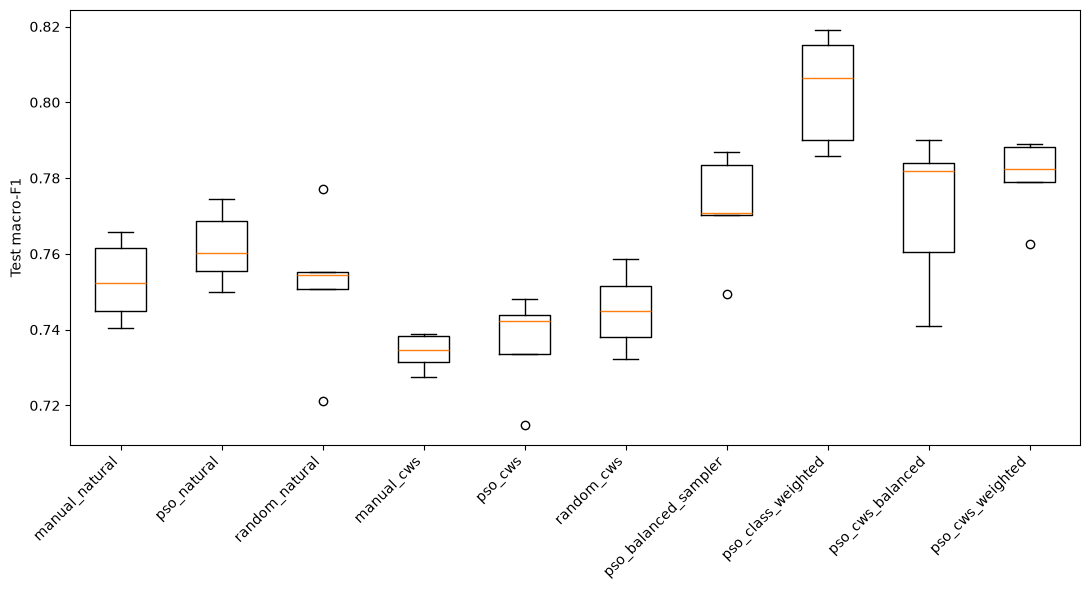

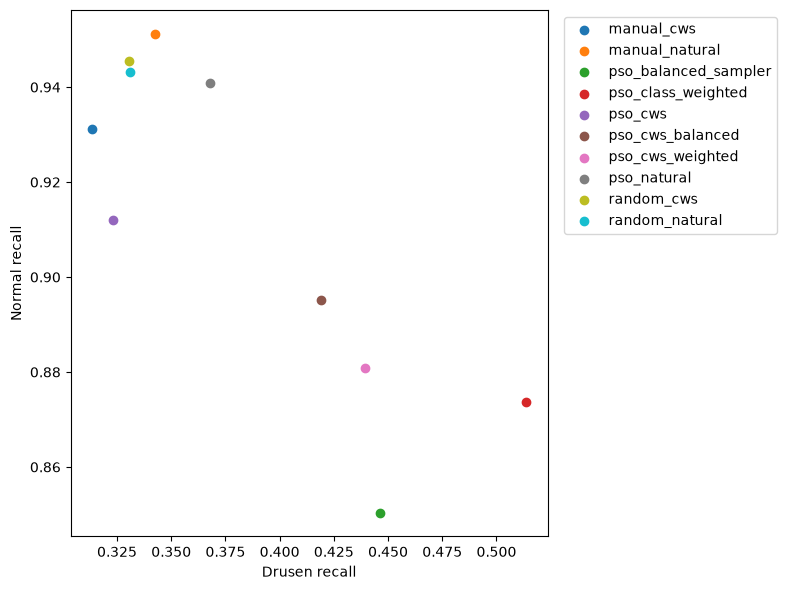

In [18]:
# Boxplot do macro-F1
plt.figure(figsize=(11, 6))
groups = [
    group["macro_f1"].to_numpy()
    for _, group in raw_results.groupby("run_name", sort=False)
]
labels = [
    name
    for name, _ in raw_results.groupby("run_name", sort=False)
]
plt.boxplot(groups, tick_labels=labels)
plt.ylabel("Test macro-F1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "macro_f1_boxplot.pdf", bbox_inches="tight")
plt.show()

# Trade-off Drusen × Normal
plt.figure(figsize=(8, 6))
for run_name, group in raw_results.groupby("run_name"):
    plt.scatter(
        group["drusen_recall"].mean(),
        group["normal_recall"].mean(),
        label=run_name,
    )
plt.xlabel("Drusen recall")
plt.ylabel("Normal recall")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "drusen_normal_tradeoff.pdf", bbox_inches="tight")
plt.show()


In [19]:
latex_columns = [
    "run_name",
    "accuracy_formatted",
    "macro_auc_formatted",
    "macro_f1_formatted",
    "mcc_formatted",
    "drusen_recall_formatted",
    "normal_recall_formatted",
]

latex_table = aggregate[latex_columns].rename(columns={
    "run_name": "Configuration",
    "accuracy_formatted": "ACC",
    "macro_auc_formatted": "AUC",
    "macro_f1_formatted": "Macro-F1",
    "mcc_formatted": "MCC",
    "drusen_recall_formatted": "Drusen REC",
    "normal_recall_formatted": "Normal REC",
})

latex_text = latex_table.to_latex(index=False, escape=False)
print(latex_text)
with open(RESULTS_DIR / "ablation_table.tex", "w", encoding="utf-8") as file:
    file.write(latex_text)

protocol = {
    "mode": MODE,
    "seeds": SEEDS,
    "dataset": "OCTMNIST official train/validation/test splits",
    "input": "1x28x28",
    "normalization": "mean=0.5, std=0.5",
    "loss": "CrossEntropyLoss; optional inverse-frequency class weights in explicit ablation",
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "scheduler": "CosineAnnealingLR",
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": PATIENCE,
    "checkpoint_criterion": "validation macro-AUC",
    "test_usage": "only after checkpoint selection",
    "cws": {
        "minority_classes": [CLASS_NAMES[i] for i in MINORITY_CLASSES],
        "clusters_per_class": CWS_N_CLUSTERS,
        "features": "raw train images reduced independently per class with PCA",
        "clusterer": "MiniBatchKMeans",
        "validation_or_test_used": False,
    },
}
with open(RESULTS_DIR / "training_protocol.json", "w", encoding="utf-8") as file:
    json.dump(protocol, file, ensure_ascii=False, indent=2)


\begin{tabular}{lllllll}
\toprule
Configuration & ACC & AUC & Macro-F1 & MCC & Drusen REC & Normal REC \\
\midrule
pso_class_weighted & 0.8132 ± 0.0124 & 0.9634 ± 0.0035 & 0.8033 ± 0.0149 & 0.7604 ± 0.0144 & 0.5136 ± 0.0540 & 0.8736 ± 0.0272 \\
pso_cws_weighted & 0.7938 ± 0.0099 & 0.9581 ± 0.0034 & 0.7802 ± 0.0107 & 0.7401 ± 0.0124 & 0.4392 ± 0.0283 & 0.8808 ± 0.0355 \\
pso_balanced_sampler & 0.7864 ± 0.0123 & 0.9589 ± 0.0023 & 0.7722 ± 0.0147 & 0.7278 ± 0.0151 & 0.4464 ± 0.0450 & 0.8504 ± 0.0524 \\
pso_cws_balanced & 0.7874 ± 0.0159 & 0.9539 ± 0.0051 & 0.7714 ± 0.0203 & 0.7312 ± 0.0173 & 0.4192 ± 0.0576 & 0.8952 ± 0.0178 \\
pso_natural & 0.7818 ± 0.0096 & 0.9611 ± 0.0037 & 0.7618 ± 0.0100 & 0.7296 ± 0.0121 & 0.3680 ± 0.0228 & 0.9408 ± 0.0222 \\
manual_natural & 0.7770 ± 0.0081 & 0.9596 ± 0.0043 & 0.7530 ± 0.0106 & 0.7242 ± 0.0107 & 0.3424 ± 0.0469 & 0.9512 ± 0.0225 \\
random_natural & 0.7768 ± 0.0128 & 0.9626 ± 0.0044 & 0.7517 ± 0.0199 & 0.7250 ± 0.0143 & 0.3312 ± 0.0572 & 0.9432 ± 0.

## 9. Checklist antes de atualizar o artigo

Use somente resultados gerados em `MODE = "final"`.

1. Reporte PSO, random search e arquitetura manual sob o mesmo protocolo.
2. Informe todos os parâmetros e o tempo total da busca.
3. Apresente média ± desvio-padrão de cinco sementes.
4. Não use AUC de validação na tabela de teste.
5. Diferencie `best_epoch` de `stop_epoch`.
6. Descreva CWS exatamente como implementado neste notebook.
7. Discuta conjuntamente recall de Drusen, precisão de Drusen e recall de Normal.
8. Não classifique amostras Normal como “borderline” sem avaliação clínica.
9. Apresente o Wilcoxon como análise exploratória: com apenas cinco pares, o poder estatístico é limitado.
10. Arquive os CSVs, previsões, matrizes e JSON do protocolo junto ao material suplementar.


In [25]:
RESULTS_DIR / "figures_publication"

PosixPath('results_medldlmo_revised_final/figures_publication')

,label,accuracy_mean,macro_auc_mean,macro_f1_mean,mcc_mean,cnv_recall_mean,dme_recall_mean,drusen_recall_mean,normal_recall_mean
0,PSO + CW,0.8132,0.9634,0.8033,0.7604,0.9656,0.9000,0.5136,0.8736
1,PSO + CWS + CW,0.7938,0.9581,0.7802,0.7401,0.9824,0.8728,0.4392,0.8808
2,PSO + BS,0.7864,0.9589,0.7722,0.7278,0.9712,0.8776,0.4464,0.8504
3,PSO + CWS + BS,0.7874,0.9539,0.7714,0.7312,0.9680,0.8672,0.4192,0.8952
4,PSO,0.7818,0.9611,0.7618,0.7296,0.9800,0.8384,0.3680,0.9408
5,Manual,0.7770,0.9596,0.7530,0.7242,0.9768,0.8376,0.3424,0.9512
6,Random,0.7768,0.9626,0.7517,0.7250,0.9792,0.8536,0.3312,0.9432
7,Random + CWS,0.7684,0.9596,0.7451,0.7150,0.9824,0.8152,0.3304,0.9456
8,PSO + CWS,0.7604,0.9554,0.7365,0.7032,0.9824,0.8240,0.3232,0.9120
9,Manual + CWS,0.7588,0.9582,0.7342,0.7029,0.9784,0.8120,0.3136,0.9312


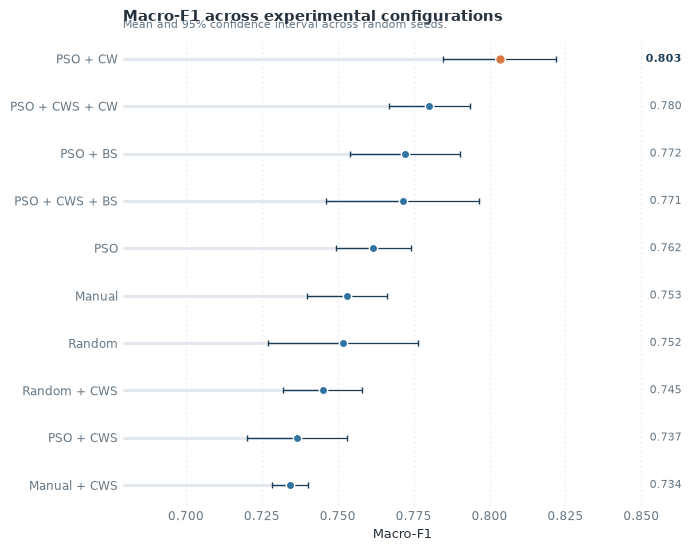

Salvo: results_medldlmo_revised_final/figures_publication_clean/01_macro_f1_ranking.pdf
Salvo: results_medldlmo_revised_final/figures_publication_clean/01_macro_f1_ranking.png


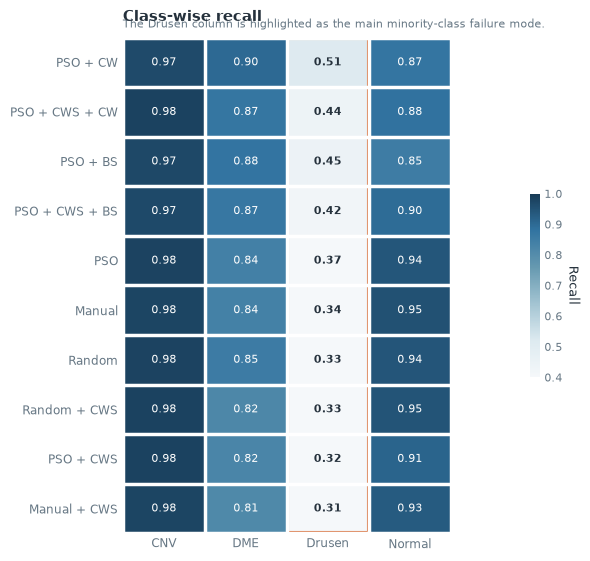

Salvo: results_medldlmo_revised_final/figures_publication_clean/02_classwise_recall.pdf
Salvo: results_medldlmo_revised_final/figures_publication_clean/02_classwise_recall.png


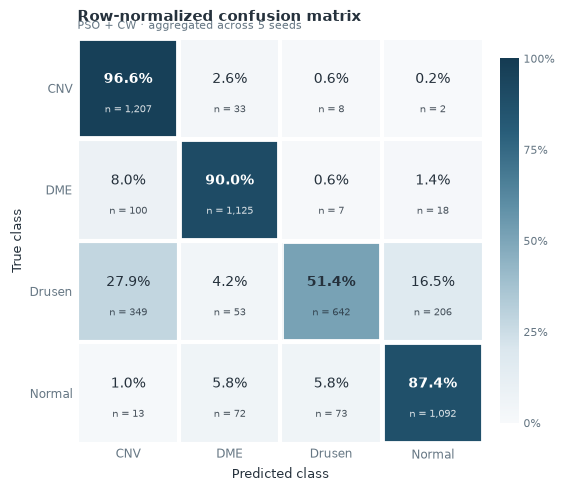

Salvo: results_medldlmo_revised_final/figures_publication_clean/03_confusion_matrix.pdf
Salvo: results_medldlmo_revised_final/figures_publication_clean/03_confusion_matrix.png

FIGURAS GERADAS
Diretório: results_medldlmo_revised_final/figures_publication_clean

01_macro_f1_ranking.pdf
02_classwise_recall.pdf
03_confusion_matrix.pdf


In [30]:
# ============================================================
# FIGURAS LIMPAS PARA O ARTIGO
#
# Saídas:
#   01_macro_f1_ranking.pdf
#   02_classwise_recall.pdf
#   03_confusion_matrix.pdf
# ============================================================

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy.stats import t

warnings.filterwarnings("ignore")

# ============================================================
# 1. Caminhos
# ============================================================

RAW_PATH = RESULTS_DIR / "raw_results.csv"
CM_DIR = RESULTS_DIR / "confusion_matrices"

FIG_DIR = RESULTS_DIR / "figures_publication_clean"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["CNV", "DME", "Drusen", "Normal"]

# ============================================================
# 2. Identidade visual
# ============================================================

NAVY = "#183B56"
BLUE = "#3274A1"
ORANGE = "#D97745"

TEXT = "#25313C"
MUTED = "#667784"
GRID = "#E2E8ED"
LIGHT = "#F3F6F8"
WHITE = "#FFFFFF"

HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "paper_blue",
    [
        "#F5F8FA",
        "#DDEAF0",
        "#A3C4D2",
        "#6699B0",
        "#3274A1",
        "#183B56",
    ],
)

CM_CMAP = LinearSegmentedColormap.from_list(
    "confusion_blue",
    [
        "#F7F9FB",
        "#DBE7EE",
        "#9DBDCC",
        "#5D8EA5",
        "#285D79",
        "#153B52",
    ],
)

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "figure.facecolor": WHITE,
    "axes.facecolor": WHITE,
    "savefig.facecolor": WHITE,
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})

# ============================================================
# 3. Funções auxiliares
# ============================================================

def save_figure(fig, filename):
    pdf_path = FIG_DIR / f"{filename}.pdf"
    png_path = FIG_DIR / f"{filename}.png"

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.08,
    )

    fig.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.08,
    )

    plt.show()
    plt.close(fig)

    print(f"Salvo: {pdf_path}")
    print(f"Salvo: {png_path}")


def clean_label(run_name):
    """Converte nomes técnicos em rótulos curtos."""

    name = str(run_name).strip().lower()

    known_names = {
        "pso_class_weighted": "PSO + CW",
        "pso_cws_weighted": "PSO + CWS + CW",
        "pso_balanced_sampler": "PSO + BS",
        "pso_cws_balanced": "PSO + CWS + BS",
        "pso_natural": "PSO",
        "manual_natural": "Manual",
        "random_natural": "Random",
        "random_cws": "Random + CWS",
        "pso_cws": "PSO + CWS",
        "manual_cws": "Manual + CWS",
    }

    if name in known_names:
        return known_names[name]

    label = (
        name
        .replace("_class_weighted", " + CW")
        .replace("_cws_weighted", " + CWS + CW")
        .replace("_balanced_sampler", " + BS")
        .replace("_cws_balanced", " + CWS + BS")
        .replace("_natural", "")
        .replace("_cws", " + CWS")
        .replace("pso", "PSO")
        .replace("manual", "Manual")
        .replace("random", "Random")
        .replace("_", " ")
    )

    return re.sub(r"\s+", " ", label).strip()


def normalize_name(value):
    return re.sub(
        r"[^a-z0-9]",
        "",
        str(value).lower(),
    )


# ============================================================
# 4. Carregamento
# ============================================================

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {RAW_PATH}"
    )

raw = pd.read_csv(RAW_PATH)

required_columns = {
    "run_name",
    "seed",
    "accuracy",
    "macro_auc",
    "macro_f1",
    "mcc",
    "cnv_recall",
    "dme_recall",
    "drusen_recall",
    "normal_recall",
}

missing = required_columns.difference(raw.columns)

if missing:
    raise ValueError(
        "Colunas ausentes: "
        + ", ".join(sorted(missing))
    )

raw["label"] = raw["run_name"].apply(clean_label)

# ============================================================
# 5. Resumo
# ============================================================

summary = (
    raw
    .groupby(
        ["run_name", "label"],
        as_index=False,
    )
    .agg(
        n=("seed", "count"),

        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        macro_auc_mean=("macro_auc", "mean"),
        macro_auc_std=("macro_auc", "std"),

        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),

        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),

        cnv_recall_mean=("cnv_recall", "mean"),
        cnv_recall_std=("cnv_recall", "std"),

        dme_recall_mean=("dme_recall", "mean"),
        dme_recall_std=("dme_recall", "std"),

        drusen_recall_mean=("drusen_recall", "mean"),
        drusen_recall_std=("drusen_recall", "std"),

        normal_recall_mean=("normal_recall", "mean"),
        normal_recall_std=("normal_recall", "std"),
    )
)

summary["macro_f1_ci95"] = summary.apply(
    lambda row: (
        t.ppf(0.975, row["n"] - 1)
        * row["macro_f1_std"]
        / np.sqrt(row["n"])
    )
    if (
        row["n"] > 1
        and pd.notna(row["macro_f1_std"])
    )
    else 0.0,
    axis=1,
)

summary = summary.sort_values(
    ["macro_f1_mean", "mcc_mean"],
    ascending=False,
).reset_index(drop=True)

summary.to_csv(
    FIG_DIR / "summary_results.csv",
    index=False,
)

display(
    summary[
        [
            "label",
            "accuracy_mean",
            "macro_auc_mean",
            "macro_f1_mean",
            "mcc_mean",
            "cnv_recall_mean",
            "dme_recall_mean",
            "drusen_recall_mean",
            "normal_recall_mean",
        ]
    ].round(4)
)

# ============================================================
# FIGURA 1
# Ranking Macro-F1
# ============================================================

ranking = summary.sort_values(
    "macro_f1_mean",
    ascending=True,
).reset_index(drop=True)

n_rows = len(ranking)

fig, ax = plt.subplots(
    figsize=(
        6.8,
        max(3.4, 0.42 * n_rows + 1.2),
    ),
    constrained_layout=True,
)

y = np.arange(n_rows)

x_min = max(
    0,
    ranking["macro_f1_mean"].min() - 0.055,
)

x_max = min(
    1,
    ranking["macro_f1_mean"].max() + 0.06,
)

best_index = ranking["macro_f1_mean"].idxmax()

for i, row in ranking.iterrows():
    is_best = i == best_index

    color = ORANGE if is_best else BLUE

    ax.hlines(
        y=i,
        xmin=x_min,
        xmax=row["macro_f1_mean"],
        color=GRID,
        linewidth=2.2,
        zorder=1,
    )

    ax.errorbar(
        row["macro_f1_mean"],
        i,
        xerr=row["macro_f1_ci95"],
        fmt="o",
        markersize=7 if is_best else 6,
        markerfacecolor=color,
        markeredgecolor=WHITE,
        markeredgewidth=1,
        ecolor=NAVY,
        elinewidth=0.9,
        capsize=2.5,
        zorder=3,
    )

    ax.text(
        x_max,
        i,
        f"{row['macro_f1_mean']:.3f}",
        ha="right",
        va="center",
        fontsize=8.2,
        fontweight="bold" if is_best else "normal",
        color=NAVY if is_best else MUTED,
    )

ax.set_yticks(y)
ax.set_yticklabels(ranking["label"])

ax.set_xlim(x_min, x_max)

ax.set_xlabel("Macro-F1")
ax.set_ylabel("")

ax.set_title(
    "Macro-F1 across experimental configurations",
    loc="left",
    fontweight="bold",
    pad=12,
)

ax.text(
    0,
    1.015,
    "Mean and 95% confidence interval across random seeds.",
    transform=ax.transAxes,
    fontsize=8,
    color=MUTED,
    va="bottom",
)

ax.xaxis.grid(
    True,
    color=GRID,
    linewidth=0.7,
    linestyle=(0, (2, 3)),
)

ax.yaxis.grid(False)
ax.tick_params(axis="both", length=0)

save_figure(
    fig,
    "01_macro_f1_ranking",
)

# ============================================================
# FIGURA 2
# Recall por classe
# ============================================================

recall_columns = [
    "cnv_recall_mean",
    "dme_recall_mean",
    "drusen_recall_mean",
    "normal_recall_mean",
]

recall_labels = [
    "CNV",
    "DME",
    "Drusen",
    "Normal",
]

recall_data = summary[
    recall_columns
].to_numpy()

fig, ax = plt.subplots(
    figsize=(
        5.8,
        max(3.6, 0.43 * len(summary) + 1.2),
    ),
    constrained_layout=True,
)

image = ax.imshow(
    recall_data,
    cmap=HEATMAP_CMAP,
    aspect="auto",
    vmin=0.40,
    vmax=1.0,
    interpolation="nearest",
)

ax.set_xticks(np.arange(4))
ax.set_xticklabels(recall_labels)

ax.set_yticks(np.arange(len(summary)))
ax.set_yticklabels(summary["label"])

for i in range(recall_data.shape[0]):
    for j in range(recall_data.shape[1]):
        value = recall_data[i, j]

        text_color = (
            WHITE
            if value >= 0.72
            else TEXT
        )

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8.2,
            fontweight="bold" if j == 2 else "normal",
            color=text_color,
        )

# Moldura discreta na coluna Drusen
ax.add_patch(
    Rectangle(
        (1.51, -0.48),
        0.98,
        len(summary) - 0.04,
        fill=False,
        edgecolor=ORANGE,
        linewidth=1.5,
    )
)

ax.set_title(
    "Class-wise recall",
    loc="left",
    fontweight="bold",
    pad=12,
)

ax.text(
    0,
    1.015,
    "The Drusen column is highlighted as the main minority-class failure mode.",
    transform=ax.transAxes,
    fontsize=8,
    color=MUTED,
    va="bottom",
)

ax.set_xticks(
    np.arange(-0.5, 4, 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, len(summary), 1),
    minor=True,
)

ax.grid(
    which="minor",
    color=WHITE,
    linewidth=2.5,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

ax.tick_params(
    axis="both",
    length=0,
)

for spine in ax.spines.values():
    spine.set_visible(False)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.028,
    pad=0.025,
)

colorbar.outline.set_visible(False)
colorbar.set_label(
    "Recall",
    rotation=270,
    labelpad=13,
)

colorbar.ax.tick_params(
    length=0,
    labelsize=8,
)

save_figure(
    fig,
    "02_classwise_recall",
)

# ============================================================
# FIGURA 3
# Matriz de confusão da melhor configuração
# ============================================================

best_run = summary.iloc[0]["run_name"]
best_label = summary.iloc[0]["label"]

if not CM_DIR.exists():
    raise FileNotFoundError(
        f"Diretório de matrizes não encontrado: {CM_DIR}"
    )

best_token = normalize_name(best_run)

cm_files = []

for path in CM_DIR.rglob("*.npy"):
    if best_token in normalize_name(path.stem):
        cm_files.append(path)

valid_matrices = []

for path in sorted(cm_files):
    try:
        matrix = np.load(
            path,
            allow_pickle=True,
        )

        if matrix.shape == (4, 4):
            valid_matrices.append(
                matrix.astype(int)
            )

    except Exception as error:
        print(
            f"Não foi possível ler {path.name}: {error}"
        )

if not valid_matrices:
    raise FileNotFoundError(
        "\nNão foi localizada uma matriz 4 × 4 para a melhor configuração.\n"
        f"Configuração: {best_run}\n"
        f"Diretório: {CM_DIR}\n\n"
        "Execute novamente a avaliação depois de adicionar "
        "save_run_confusion_matrix(...)."
    )

cm = np.sum(
    valid_matrices,
    axis=0,
).astype(int)

row_totals = cm.sum(
    axis=1,
    keepdims=True,
)

cm_normalized = np.divide(
    cm,
    row_totals,
    out=np.zeros_like(
        cm,
        dtype=float,
    ),
    where=row_totals != 0,
)

fig, ax = plt.subplots(
    figsize=(5.6, 4.8),
    constrained_layout=True,
)

image = ax.imshow(
    cm_normalized,
    cmap=CM_CMAP,
    vmin=0,
    vmax=1,
    interpolation="nearest",
    aspect="equal",
)

for i in range(4):
    for j in range(4):
        proportion = cm_normalized[i, j]
        count = int(cm[i, j])

        text_color = (
            WHITE
            if proportion >= 0.55
            else TEXT
        )

        ax.text(
            j,
            i - 0.09,
            f"{proportion * 100:.1f}%",
            ha="center",
            va="center",
            fontsize=10.2,
            fontweight="bold" if i == j else "normal",
            color=text_color,
        )

        ax.text(
            j,
            i + 0.21,
            f"n = {count:,}",
            ha="center",
            va="center",
            fontsize=7,
            color=text_color,
            alpha=0.82,
        )

# Bordas discretas na diagonal
for index in range(4):
    ax.add_patch(
        Rectangle(
            (
                index - 0.48,
                index - 0.48,
            ),
            0.96,
            0.96,
            fill=False,
            edgecolor=WHITE,
            linewidth=1.3,
        )
    )

ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(4))

ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")

ax.set_title(
    "Row-normalized confusion matrix",
    loc="left",
    fontweight="bold",
    pad=12,
)

ax.text(
    0,
    1.015,
    (
        f"{best_label} · "
        f"aggregated across {len(valid_matrices)} seeds"
    ),
    transform=ax.transAxes,
    fontsize=8,
    color=MUTED,
    va="bottom",
)

ax.set_xticks(
    np.arange(-0.5, 4, 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, 4, 1),
    minor=True,
)

ax.grid(
    which="minor",
    color=WHITE,
    linewidth=3,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

ax.tick_params(
    axis="both",
    length=0,
)

for spine in ax.spines.values():
    spine.set_visible(False)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.038,
    pad=0.035,
)

colorbar.outline.set_visible(False)

colorbar.set_ticks(
    [0, 0.25, 0.50, 0.75, 1.0]
)

colorbar.set_ticklabels(
    ["0%", "25%", "50%", "75%", "100%"]
)

colorbar.ax.tick_params(
    length=0,
    labelsize=8,
)

save_figure(
    fig,
    "03_confusion_matrix",
)

# ============================================================
# Finalização
# ============================================================

print()
print("=" * 68)
print("FIGURAS GERADAS")
print("=" * 68)
print(f"Diretório: {FIG_DIR}")
print()
print("01_macro_f1_ranking.pdf")
print("02_classwise_recall.pdf")
print("03_confusion_matrix.pdf")